# 04 - Classical Detection and Segmentation

Four HOG sliding-window linear-SVM detectors localize upper garments, bottoms, footwear, and headwear using deterministic negatives, NMS, and a full-profile hard-negative pass. GrabCut, morphology, and largest-connected-component filtering segment each retained box.

In [1]:
import csv,sys
from pathlib import Path
import matplotlib.pyplot as plt
cwd=Path.cwd().resolve(); REPO=next((p for p in [cwd,*cwd.parents] if (p/'implementation'/'src').exists()),None)
if REPO is None: raise RuntimeError('Start Jupyter inside the repository.')
sys.path.insert(0,str(REPO/'implementation'/'src'))
from ipcv_attire.dataset_policy import load_policy,require_showcase_approval
from ipcv_attire.pipeline import AttirePipeline
from ipcv_attire.preprocessing import preprocess_image
from ipcv_attire.training import train_pipeline
from ipcv_attire.visualization import draw_detections,draw_masks
DATA=REPO/'implementation'/'data'; POLICY=load_policy(DATA/'dataset-policy.json'); BUNDLE=REPO/'implementation'/'models'/'classical-attire-smoke'
if not (BUNDLE/'manifest.json').exists(): train_pipeline(manifest_dir=DATA/'interim'/'manifests',fashionpedia_root=DATA/'raw'/'fashionpedia',policy=POLICY,bundle_dir=BUNDLE,profile_name='smoke')
pipeline=AttirePipeline.load(BUNDLE)


30 post-NMS detections
{'component': 'bottom_body', 'bbox': [48, 0, 112, 96], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'bottom_body', 'bbox': [96, 0, 160, 96], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'bottom_body', 'bbox': [128, 0, 192, 96], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'bottom_body', 'bbox': [176, 0, 240, 96], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'bottom_body', 'bbox': [208, 0, 272, 96], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'bottom_body', 'bbox': [384, 0, 448, 96], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'bottom_body', 'bbox': [432, 0, 496, 96], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'bottom_body', 'bbox': [0, 24, 64, 120], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'footwear', 'bbox': [176, 16, 240, 80], 'score': 1.0, 'source': 'hog_linear_svm'}
{'component': 'footwear', 'bbox': [176, 48, 240, 112], 'score': 1.0, 'source': 'hog_linear_svm'}
{'c

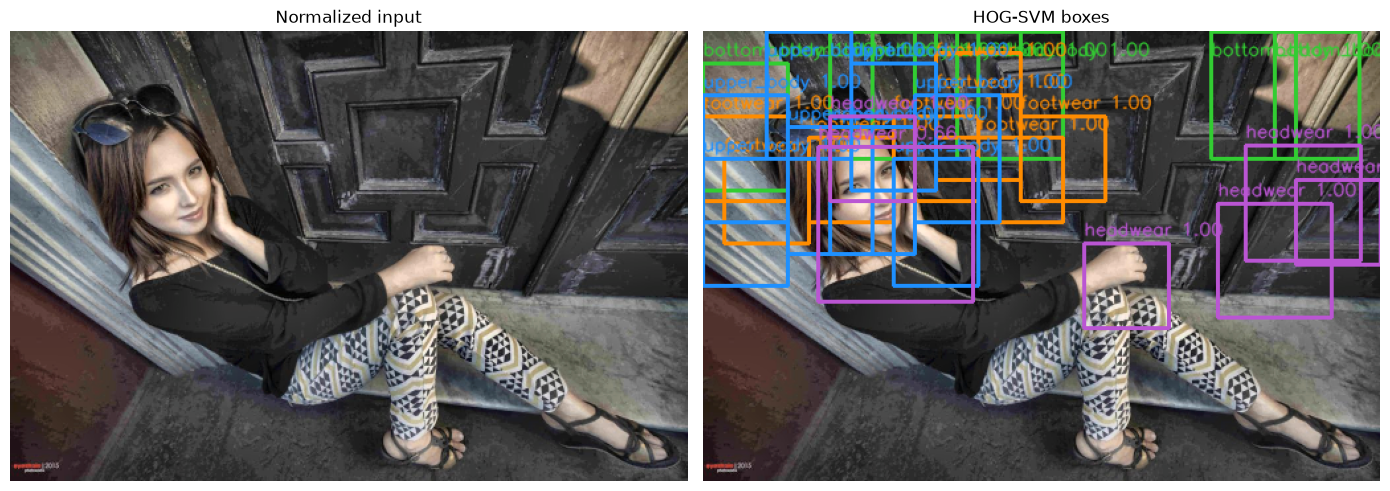

In [2]:
DEMO_IMAGE_ID='13665'
with (DATA/'interim'/'manifests'/'fashionpedia-images.csv').open(encoding='utf-8',newline='') as handle: record=next(r for r in csv.DictReader(handle) if r['image_id']==DEMO_IMAGE_ID)
require_showcase_approval(DEMO_IMAGE_ID,DATA/'showcase-manifest.csv',display_risk=record['display_risk']=='1')
image_path=DATA/'raw'/'fashionpedia'/record['relative_image_path']; prepared=preprocess_image(image_path,maximum_side=POLICY['pipeline']['maximum_image_side']); detections=pipeline.detector.detect(prepared.normalized_rgb)
print(f'{len(detections)} post-NMS detections'); [print(d.to_dict()) for d in detections]
fig,axes=plt.subplots(1,2,figsize=(14,6)); axes[0].imshow(prepared.normalized_rgb); axes[0].set_title('Normalized input'); axes[1].imshow(draw_detections(prepared.normalized_rgb,detections)); axes[1].set_title('HOG-SVM boxes'); [a.axis('off') for a in axes]; plt.tight_layout()


## GrabCut masks and safeguards

Empty, failed, or implausible-area masks retain warnings and force review. Locked evaluation decodes Fashionpedia polygon/RLE masks and compares GrabCut with a rectangular-box baseline.

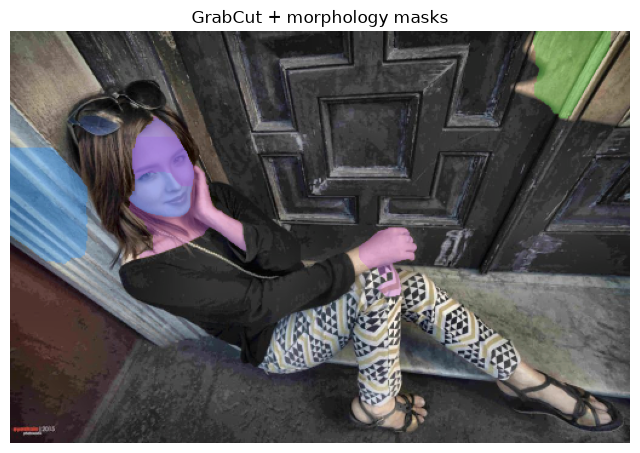

component-1 upper_body valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-2 bottom_body valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-3 upper_body valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-4 bottom_body valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-5 headwear valid= True area= 0.394 warnings= []
component-6 upper_body valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-7 bottom_body valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-8 footwear valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-9 footwear valid= False area= 0.0 warnings= ['Mask area ratio 0.000 is outside quality limits.']
component-10 upper_body valid= False area= 0.0 warnings= ['Mask area ra

In [3]:
report=pipeline.analyze(image_path); components=[c for o in report.outfits for c in o.components]
plt.figure(figsize=(8,8)); plt.imshow(draw_masks(prepared.normalized_rgb,components)); plt.axis('off'); plt.title('GrabCut + morphology masks'); plt.show()
for c in components: print(c.component_id,c.detection.component,'valid=',c.segmentation_valid,'area=',round(c.mask_area_ratio,3),'warnings=',c.warnings)


## Metrics

The frozen locked test reports detection precision, recall, AP/AP50 and segmentation IoU/Dice. No locked-test result is used for retuning.